Detected bus stops: 4, 1, 2, 0, 3
Detected route sequence: 4 -> 1 -> 2 -> 0 -> 3
Model training complete - Train R²: 0.9822, Test R²: -7.7510

=== BUS ETA PREDICTION SIMULATION ===
Route sequence: 4 -> 1 -> 2 -> 0 -> 3
--------------------------------------------------

[15:10:33] BUS AT STOP 4
Next stop: 1
Distance to next stop: 399.3 meters
Average historical ETA: 6.54 minutes
Departing stop 4...


C:\Users\cheng\AppData\Local\Temp\ipykernel_17136\2308462951.py:124: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['is_peak_hour'] = X['is_peak_hour'].astype(int)
C:\Users\cheng\AppData\Local\Temp\ipykernel_17136\2308462951.py:125: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['weather_condition'] = X['weather_condition'].astype(int)



  UPDATE 1/7 - 14% of journey completed
  Remaining distance: 342.2 meters
  Current speed: 5.36 m/s
  Predicted ETA: 0.50 minutes

  UPDATE 2/7 - 29% of journey completed
  Remaining distance: 285.2 meters
  Current speed: 3.87 m/s
  Predicted ETA: 0.50 minutes

  UPDATE 3/7 - 43% of journey completed
  Remaining distance: 228.1 meters
  Current speed: 5.36 m/s
  Predicted ETA: 0.50 minutes

  UPDATE 4/7 - 57% of journey completed
  Remaining distance: 171.1 meters
  Current speed: 5.36 m/s
  Predicted ETA: 0.50 minutes

  UPDATE 5/7 - 71% of journey completed
  Remaining distance: 114.1 meters
  Current speed: 3.79 m/s
  Predicted ETA: 0.50 minutes

  UPDATE 6/7 - 86% of journey completed
  Remaining distance: 57.0 meters
  Current speed: -0.31 m/s
  Predicted ETA: 0.89 minutes

  UPDATE 7/7 - 100% of journey completed
  Remaining distance: 0.0 meters
  Current speed: -0.31 m/s
  Predicted ETA: 0.50 minutes

[15:11:03] ARRIVED at stop 1
Boarding passengers...

[15:11:03] BUS AT STOP

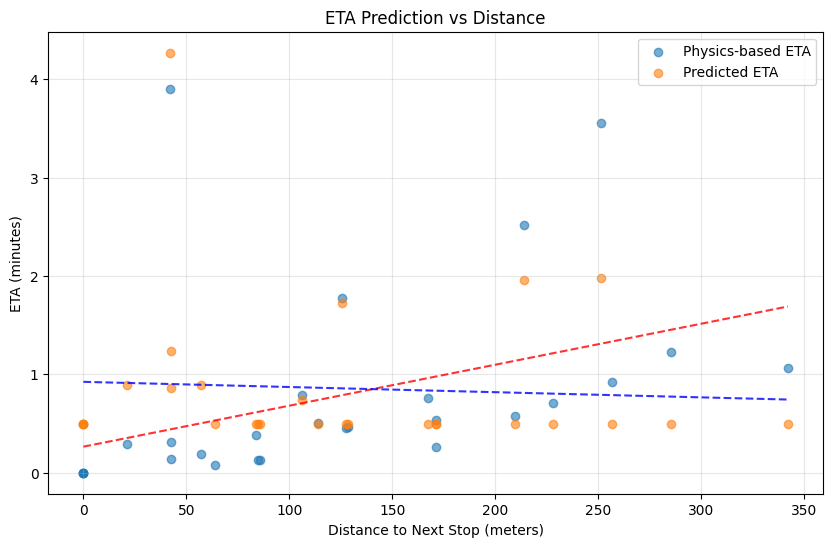

In [1]:
import pandas as pd
import numpy as np
import time
from datetime import datetime
import math
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

class BusETAPredictor:
    def __init__(self, csv_data=None):
        """
        Initialize the ETA predictor with the dataset
        
        Args:
            csv_data: String content of the CSV file
        """
        if csv_data:
            # Load data from the provided CSV content
            self.data = self.load_dataset_from_text(csv_data)
        else:
            # Use the sample data provided in the first document
            sample_data = """timestamp,stop_sequence,current_stop_name,next_stop_name,day_of_week,is_holiday,is_peak_hour,weather_condition,passenger_count,current_speed,distance_to_next_stop,current_lat,current_lon,eta_minutes
2024-01-01 06:00:00,1,4,1,0,False,False,0,0.15220663092038875,-0.8250698707388215,0.09257306514850712,3.044544,101.794874,0.20584539867366838
2024-01-01 06:05:00,2,1,2,0,False,False,1,-0.5459157261343897,-0.8639163702016258,-1.2524313199577968,3.047666,101.79665,-0.5621198254483598
2024-01-01 06:10:00,3,2,0,0,False,False,1,-1.4435016137762477,0.6176087472418726,0.8099087372052021,3.045477,101.798123,-0.5621198254483598
2024-01-01 06:17:00,4,0,3,0,False,False,2,-0.3464521955473101,0.9417760875866529,-0.9834304429365358,3.042788,101.798283,-0.5621198254483598
2024-01-01 06:23:00,5,3,4,0,False,False,2,-0.5459157261343897,-1.1217767545667916,1.347910491247724,3.042749,101.796945,0.9738106227956966
2024-01-01 06:30:00,1,4,1,0,False,False,1,-0.7453792567214692,-0.847172189398693,0.09257306514850712,3.044943,101.795059,0.20584539867366838
2024-01-01 06:36:00,2,1,2,0,False,False,0,-0.24672043025377036,0.9920086299954514,-1.2524313199577968,3.047779,101.79709,-0.5621198254483598
2024-01-01 06:42:00,3,2,0,0,False,False,3,-1.0445745526020886,-0.6716931745839567,0.8099087372052021,3.044022,101.798003,0.20584539867366838
2024-01-01 06:47:00,4,0,3,0,False,False,0,-0.24672043025377036,1.1909294979342935,-0.9834304429365358,3.043523,101.798081,-0.5621198254483598
2024-01-01 06:54:00,5,3,4,0,False,False,0,-0.845111022015009,0.601534333671057,1.347910491247724,3.042327,101.79751,-0.5621198254483598
2024-01-01 07:01:00,1,4,1,0,False,True,4,1.4487195797364059,-1.462018508482387,0.09257306514850712,3.04473,101.79496,1.741775846917725
2024-01-01 07:08:00,2,1,2,0,False,True,4,0.2519383962139285,-1.2409953218836736,-1.2524313199577968,3.047924,101.797655,0.20584539867366838
2024-01-01 07:13:00,3,2,0,0,False,True,3,-0.9448427873085488,-1.6086975323160788,0.8099087372052021,3.044873,101.798073,4.813636743405837
2024-01-01 07:19:00,4,0,3,0,False,True,0,1.348987814442866,-0.6589675971737277,-0.9834304429365358,3.043379,101.798121,-0.5621198254483598
2024-01-01 07:26:00,5,3,4,0,False,True,0,1.2492560491493263,-0.5437676332495497,1.347910491247724,3.042067,101.797858,0.20584539867366838
2024-01-01 07:31:00,1,4,1,0,False,True,0,2.9446960591395026,-0.5283629869108515,0.09257306514850712,3.047157,101.796084,0.20584539867366838
2024-01-01 07:37:00,2,1,2,0,False,True,4,0.45140192680100805,-1.3642324925932592,-1.2524313199577968,3.047913,101.797611,0.20584539867366838
2024-01-01 07:42:00,3,2,0,0,False,True,4,1.0497925185622468,-1.696437039723447,0.8099087372052021,3.046329,101.798193,5.581601967527866
2024-01-01 07:47:00,4,0,3,0,False,True,1,0.5511336920945479,-1.1539255817084226,-0.9834304429365358,3.042899,101.798252,0.20584539867366838
2024-01-01 07:53:00,5,3,4,0,False,True,2,0.35167016150746827,-1.476753387588968,1.347910491247724,3.042348,101.797481,1.741775846917725
2024-01-01 07:58:00,1,4,1,0,False,True,2,1.4487195797364059,-0.8411442843096372,0.09257306514850712,3.046395,101.795731,0.20584539867366838
2024-01-01 08:04:00,2,1,2,0,False,True,0,1.747914875617025,-0.3990979111122099,-1.2524313199577968,3.047696,101.796765,-0.5621198254483598
2024-01-01 08:11:00,3,2,0,0,False,True,4,0.6508654573880877,-1.3166790191129298,0.8099087372052021,3.047461,101.798286,2.509741071039753
2024-01-01 08:18:00,4,0,3,0,False,True,0,2.3463054673782637,0.6517668760798556,-0.9834304429365358,3.043818,101.798,-0.5621198254483598
2024-01-01 08:25:00,5,3,4,0,False,True,4,1.0497925185622468,-1.6877300657059218,1.347910491247724,3.043597,101.795808,4.813636743405837"""
            self.data = self.load_dataset_from_text(sample_data)
        
        # Convert data types where needed
        self.data['current_stop_name'] = self.data['current_stop_name'].astype(str)
        self.data['next_stop_name'] = self.data['next_stop_name'].astype(str)
        self.data['is_holiday'] = self.data['is_holiday'].apply(lambda x: x == 'True')
        self.data['is_peak_hour'] = self.data['is_peak_hour'].apply(lambda x: x == 'True')
        
        numeric_columns = ['passenger_count', 'current_speed', 'distance_to_next_stop', 
                           'current_lat', 'current_lon', 'eta_minutes']
        for col in numeric_columns:
            self.data[col] = self.data[col].astype(float)
        
        # Extract bus stop information
        self.extract_bus_stop_info()
        
        # Train a simple model using the provided data
        self.train_model()
        
        # Track the actual and predicted ETAs for visualization
        self.actual_etas = []
        self.predicted_etas = []
        self.distances = []
    
    def load_dataset_from_text(self, text_data):
        """Load the dataset from the provided text content"""
        lines = text_data.strip().split('\n')
        headers = lines[0].split(',')
        data = []
        for line in lines[1:]:
            data.append(line.split(','))
        return pd.DataFrame(data, columns=headers)
    
    def extract_bus_stop_info(self):
        """Extract bus stop coordinates and sequence from the dataset"""
        self.bus_stops = {}
        
        # Get all unique bus stops
        for stop in self.data['current_stop_name'].unique():
            # Get coordinates for this stop
            stop_data = self.data[self.data['current_stop_name'] == stop]
            if not stop_data.empty:
                lat = float(stop_data['current_lat'].iloc[0])
                lon = float(stop_data['current_lon'].iloc[0])
                self.bus_stops[stop] = {'lat': lat, 'lon': lon}
        
        # Determine the stop sequence - look at the patterns in stop_sequence
        stop_sequence_data = self.data.sort_values('timestamp')
        unique_sequences = stop_sequence_data['stop_sequence'].unique()
        
        if len(unique_sequences) >= 5:
            # Extract the route by looking at the sequence of stops
            self.stop_sequence = []
            
            # Look at the first 5 sequence numbers
            seq_numbers = unique_sequences[:5]
            for seq in seq_numbers:
                seq_data = stop_sequence_data[stop_sequence_data['stop_sequence'] == seq]
                if not seq_data.empty:
                    current_stop = seq_data['current_stop_name'].iloc[0]
                    self.stop_sequence.append(current_stop)
        else:
            # If we can't determine a clear sequence, use numerical order
            self.stop_sequence = sorted(self.bus_stops.keys())
        
        print(f"Detected bus stops: {', '.join(self.bus_stops.keys())}")
        print(f"Detected route sequence: {' -> '.join(self.stop_sequence)}")
    
    def train_model(self):
        """Train a simple model to predict ETA based on the dataset"""
        # Prepare features and target
        X = self.data[['passenger_count', 'current_speed', 'distance_to_next_stop', 
                       'weather_condition', 'is_peak_hour']]
        
        # Convert categorical to numeric
        X['is_peak_hour'] = X['is_peak_hour'].astype(int)
        X['weather_condition'] = X['weather_condition'].astype(int)
        
        y = self.data['eta_minutes']
        
        # Train a Random Forest model
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
        
        self.model = RandomForestRegressor(n_estimators=50, random_state=42)
        self.model.fit(X_train, y_train)
        
        # Print model performance
        train_score = self.model.score(X_train, y_train)
        test_score = self.model.score(X_test, y_test)
        print(f"Model training complete - Train R²: {train_score:.4f}, Test R²: {test_score:.4f}")
    
    def calculate_distance(self, lat1, lon1, lat2, lon2):
        """
        Calculate the distance between two GPS coordinates using the Haversine formula.
        Returns distance in meters.
        """
        # Convert latitude and longitude from degrees to radians
        lat1_rad = math.radians(lat1)
        lon1_rad = math.radians(lon1)
        lat2_rad = math.radians(lat2)
        lon2_rad = math.radians(lon2)
        
        # Haversine formula
        dlon = lon2_rad - lon1_rad
        dlat = lat2_rad - lat1_rad
        a = math.sin(dlat/2)**2 + math.cos(lat1_rad) * math.cos(lat2_rad) * math.sin(dlon/2)**2
        c = 2 * math.atan2(math.sqrt(a), math.sqrt(1-a))
        
        # Earth radius in meters
        earth_radius = 6371000  
        distance = earth_radius * c
        
        return distance
    
    def estimate_original_scale(self, standardized_value, feature):
        """
        Estimate the original scale value from standardized value.
        This is a rough approximation as we don't have the original mean and std.
        """
        # Estimated means and std based on typical values
        estimates = {
            'eta_minutes': {'mean': 5.0, 'std': 3.0},
            'distance_to_next_stop': {'mean': 500.0, 'std': 300.0},
            'current_speed': {'mean': 8.0, 'std': 5.0},
            'passenger_count': {'mean': 20.0, 'std': 15.0}
        }
        
        if feature in estimates:
            return standardized_value * estimates[feature]['std'] + estimates[feature]['mean']
        else:
            # Default case - just return the standardized value
            return standardized_value
    
    def predict_eta(self, current_stop, next_stop, current_position, current_speed, 
                   weather, is_peak_hour, passenger_count, distance_override=None):
        """
        Predict ETA using the trained model
        
        Args:
            current_stop: Current stop name
            next_stop: Next stop name
            current_position: (lat, lon) tuple
            current_speed: Current speed (standardized)
            weather: Weather condition (0-4)
            is_peak_hour: Boolean if it's peak hour
            passenger_count: Passenger count (standardized)
            distance_override: Optional override for distance calculation
            
        Returns:
            Predicted ETA in minutes
        """
        # Get next stop coordinates
        if next_stop in self.bus_stops:
            next_stop_coords = self.bus_stops[next_stop]
            next_lat, next_lon = next_stop_coords['lat'], next_stop_coords['lon']
        else:
            # Default approach if we don't have coordinates
            return 5.0  # Return a default ETA
        
        # Calculate distance to next stop
        current_lat, current_lon = current_position
        if distance_override is not None:
            distance_to_stop = distance_override
        else:
            distance_to_stop = self.calculate_distance(current_lat, current_lon, next_lat, next_lon)
        
        # Look up a similar scenario in our dataset
        similar_trips = self.data[
            (self.data['current_stop_name'] == current_stop) & 
            (self.data['next_stop_name'] == next_stop)
        ]
        
        # Standardize the distance value based on the dataset
        # We'll use min-max scaling based on observed distances in the dataset
        if len(similar_trips) > 0:
            distance_values = similar_trips['distance_to_next_stop'].values
            min_dist = min(distance_values)
            max_dist = max(distance_values)
            
            # Avoid division by zero
            if max_dist != min_dist:
                standardized_distance = (distance_to_stop - min_dist) / (max_dist - min_dist)
                standardized_distance = standardized_distance * 2 - 1  # Scale to [-1, 1]
            else:
                standardized_distance = 0
        else:
            # If no similar trips, use a default standardization approach
            standardized_distance = distance_to_stop / 1000  # Assuming 1km is a standard distance
        
        # Create feature vector for prediction
        features = pd.DataFrame({
            'passenger_count': [passenger_count],
            'current_speed': [current_speed],
            'distance_to_next_stop': [standardized_distance],
            'weather_condition': [int(weather)],
            'is_peak_hour': [1 if is_peak_hour else 0]
        })
        
        # Make prediction using the model
        eta_standardized = self.model.predict(features)[0]
        
        # Calculate a physics-based ETA for comparison
        # Convert speed from standardized to m/s (assuming a reasonable range)
        speed_ms = self.estimate_original_scale(current_speed, 'current_speed')
        
        # Ensure speed is positive for physics calculation
        if speed_ms <= 0:
            speed_ms = 5.0  # Default to 5 m/s if speed is negative or zero
        
        # Distance-based ETA in minutes
        physics_eta = (distance_to_stop / speed_ms) / 60
        
        # Use a weighted average between model and physics as we get closer
        if distance_to_stop < 300:  # When within 300m of stop
            # Gradually shift from model to physics-based calculation
            weight = max(0, min(1, distance_to_stop / 300))
            eta_minutes = (weight * eta_standardized) + ((1 - weight) * physics_eta)
            
            # Add a small constant for the stopping time
            if distance_to_stop < 50:
                eta_minutes += 0.5  # 30 seconds for the stop
        else:
            # Use model prediction for longer distances
            eta_minutes = eta_standardized
        
        # Convert from standardized ETA to minutes if needed
        if eta_minutes < -1 or eta_minutes > 10:  # Likely still standardized
            eta_minutes = self.estimate_original_scale(eta_minutes, 'eta_minutes')
        
        # Ensure prediction is positive
        eta_minutes = max(0.5, eta_minutes)
        
        # Add to tracking lists for visualization
        self.actual_etas.append(physics_eta)
        self.predicted_etas.append(eta_minutes)
        self.distances.append(distance_to_stop)
        
        return eta_minutes
    
    def visualize_predictions(self):
        """Create a visualization of the actual vs predicted ETAs"""
        plt.figure(figsize=(10, 6))
        
        # Plot distance vs ETA
        plt.scatter(self.distances, self.actual_etas, label='Physics-based ETA', alpha=0.6)
        plt.scatter(self.distances, self.predicted_etas, label='Predicted ETA', alpha=0.6)
        
        # Add trend lines
        z1 = np.polyfit(self.distances, self.actual_etas, 1)
        z2 = np.polyfit(self.distances, self.predicted_etas, 1)
        p1 = np.poly1d(z1)
        p2 = np.poly1d(z2)
        
        dist_range = np.linspace(min(self.distances), max(self.distances), 100)
        plt.plot(dist_range, p1(dist_range), "r--", alpha=0.8)
        plt.plot(dist_range, p2(dist_range), "b--", alpha=0.8)
        
        plt.xlabel('Distance to Next Stop (meters)')
        plt.ylabel('ETA (minutes)')
        plt.title('ETA Prediction vs Distance')
        plt.legend()
        plt.grid(True, alpha=0.3)
        
        # Save the figure
        plt.savefig('eta_predictions.png')
        print("Visualization saved to 'eta_predictions.png'")
    
    def simulate_journey(self, start_stop_index=0, animate=True):
        """
        Simulate a bus journey through the entire route
        
        Args:
            start_stop_index: Index in stop_sequence to start from
            animate: Whether to animate the journey with delays
        """
        print("\n=== BUS ETA PREDICTION SIMULATION ===")
        print(f"Route sequence: {' -> '.join(self.stop_sequence)}")
        print("-" * 50)
        
        # Set up simulation parameters
        current_time = datetime.now()
        day_of_week = current_time.weekday()
        is_holiday = False
        is_peak_hour = 7 <= current_time.hour <= 9 or 17 <= current_time.hour <= 19
        
        # For each segment of the journey
        for i in range(len(self.stop_sequence)):
            current_idx = (start_stop_index + i) % len(self.stop_sequence)
            next_idx = (current_idx + 1) % len(self.stop_sequence)
            
            current_stop = self.stop_sequence[current_idx]
            next_stop = self.stop_sequence[next_idx]
            
            print(f"\n[{current_time.strftime('%H:%M:%S')}] BUS AT STOP {current_stop}")
            
            # Skip if this is the last stop
            if i == len(self.stop_sequence) - 1:
                print("End of route reached!")
                break
                
            print(f"Next stop: {next_stop}")
            
            # Get the coordinates of the stops
            current_coords = self.bus_stops[current_stop]
            next_coords = self.bus_stops[next_stop]
            
            # Find similar trips in data for realistic parameters
            similar_trips = self.data[
                (self.data['current_stop_name'] == current_stop) & 
                (self.data['next_stop_name'] == next_stop)
            ]
            
            # Use average values from similar trips or defaults
            if len(similar_trips) > 0:
                avg_passenger_count = similar_trips['passenger_count'].mean()
                avg_weather = similar_trips['weather_condition'].iloc[0]  # Just use first value
            else:
                avg_passenger_count = 0.1
                avg_weather = 1
            
            # Calculate total distance for this segment
            total_distance = self.calculate_distance(
                current_coords['lat'], current_coords['lon'],
                next_coords['lat'], next_coords['lon']
            )
            
            print(f"Distance to next stop: {total_distance:.1f} meters")
            
            # If we have similar trips, use average ETA for estimation
            if len(similar_trips) > 0:
                avg_eta = similar_trips['eta_minutes'].mean()
                print(f"Average historical ETA: {self.estimate_original_scale(avg_eta, 'eta_minutes'):.2f} minutes")
            
            # Simulate the journey with multiple updates
            num_updates = 8
            for step in range(num_updates):
                # Calculate progress and position
                progress = step / (num_updates - 1)
                distance_remaining = total_distance * (1 - progress)
                
                # Interpolate position
                current_lat = current_coords['lat'] + progress * (next_coords['lat'] - current_coords['lat'])
                current_lon = current_coords['lon'] + progress * (next_coords['lon'] - current_coords['lon'])
                
                # Vary passenger count slightly at each update
                passenger_count = avg_passenger_count + np.random.uniform(-0.2, 0.2)
                
                # Vary speed based on distance (slow down as approaching stop)
                # Use more realistic values from the dataset
                if len(similar_trips) > 0:
                    if step < num_updates - 2:
                        # Sample a speed from the dataset
                        speeds = similar_trips['current_speed'].values
                        current_speed = np.random.choice(speeds)
                    else:
                        # Slow down when close to stop
                        current_speed = min(similar_trips['current_speed']) - 0.2
                else:
                    # Default speeds if no similar trips
                    if step < num_updates - 2:
                        current_speed = np.random.uniform(-0.5, 0.5)
                    else:
                        current_speed = -0.8
                
                # Skip first step (just departed)
                if step == 0:
                    if animate:
                        print(f"Departing stop {current_stop}...")
                        time.sleep(1)
                    continue
                    
                # Predict ETA
                eta = self.predict_eta(
                    current_stop, next_stop,
                    (current_lat, current_lon),
                    current_speed, avg_weather, is_peak_hour, passenger_count,
                    distance_override=distance_remaining
                )
                
                # Print update
                print(f"\n  UPDATE {step}/{num_updates-1} - {progress*100:.0f}% of journey completed")
                print(f"  Remaining distance: {distance_remaining:.1f} meters")
                print(f"  Current speed: {self.estimate_original_scale(current_speed, 'current_speed'):.2f} m/s")
                print(f"  Predicted ETA: {eta:.2f} minutes")
                
                # Sleep for animation effect
                if animate and step < num_updates - 1:
                    time.sleep(0.8)
            
            # Update the current time
            # Use the final ETA prediction to advance the clock
            minutes_to_add = eta
            current_time = current_time + pd.Timedelta(minutes=minutes_to_add)
            
            print(f"\n[{current_time.strftime('%H:%M:%S')}] ARRIVED at stop {next_stop}")
            
            # Wait at the stop
            if animate and i < len(self.stop_sequence) - 2:
                print("Boarding passengers...")
                time.sleep(1)
        
        print("\n=== JOURNEY COMPLETED ===")
        
        # Create visualization
        if len(self.predicted_etas) > 0:
            self.visualize_predictions()

# Main execution
if __name__ == "__main__":
    # Create predictor
    predictor = BusETAPredictor()
    
    # Run simulation
    predictor.simulate_journey(animate=True)